# Missing values in adaptive n-of-1 trials

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy
from adaptive_nof1 import *
from adaptive_nof1.policies import *
from adaptive_nof1.helpers import *
from adaptive_nof1.inference import *
from adaptive_nof1.metrics import *
from matplotlib import pyplot as plt

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [3]:
import random

import seaborn as sns

import sys
sys.path.append("..")

from missingness.missing_utils import *
import copy
from ast import literal_eval

/mnt/c/Users/Juliana/dev/adaptive_nof1/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Initial parameters 
block_length = 1
length = 28
number_of_actions = 2
number_of_patients = 100
percentage_missing = 0.3
num_patients_missing = 50
missing_mechanism = "random"
imputation_method_names = [ "global","individual"]#,  "knn", "locf","ind_tr", "global_tr", "cluster", "dr"]

#random.seed(9001)
#np.random.seed(9001)
treatment_means = [2,2]
treatment_vars = [1,1]
effect_parameters_file_ending = f"{treatment_means[0]}{treatment_means[1]}"

In [5]:
results_path = "../missingness/results/test"

In [6]:
exists = False
save = True

In [7]:
generating_scenario_II = lambda patient_id: NormalModel(
    patient_id, mean=literal_eval(repr(treatment_means)), variance=[1, 1]
)

model_mapping = {
    f"NormalModel(({repr(treatment_means)}, [1, 1]))": "II",
}
policy_mapping = {
    "BlockPolicy(ThompsonSampling(NormalKnownVariance(0, 1, 1)))": "TS",
}

# Inference Model
inference_model = lambda: NormalKnownVariance(
    prior_mean=0, prior_variance=1, variance=1
)
# Set global random seed
np.random.seed(9001)

# Initialize policies separately with deep copies
thompson_sampling_policy_1 = BlockPolicy(
    block_length=block_length,
    internal_policy=ThompsonSampling(
        inference_model=inference_model(),
    ),
)

np.random.seed(9001)  # Reset seed again before second policy
thompson_sampling_policy_2 = copy.deepcopy(thompson_sampling_policy_1)


study_designs = {
    "n_patients": [number_of_patients],
    "model_from_patient_id": [generating_scenario_II],
    "policy_full": [
       thompson_sampling_policy_1
    ],
    "policy_miss": [
      thompson_sampling_policy_2
    ],
    "pooling": [False],
}

configurations_ind = generate_configuration_cross_product(study_designs)
configurations_ind

[{'n_patients': 100,
  'model_from_patient_id': <function __main__.<lambda>(patient_id)>,
  'policy_full': <adaptive_nof1.policies.block_policy.BlockPolicy at 0x7f2a1e79dfc0>,
  'policy_miss': <adaptive_nof1.policies.block_policy.BlockPolicy at 0x7f2a1e79dae0>,
  'pooling': False}]

In [8]:
configurations_ind[0]["policy_miss"].internal_policy.rng.bit_generator.state

{'bit_generator': 'PCG64',
 'state': {'state': 133851709565500680716510354055160881430,
  'inc': 291458793928450121768714117184161527819},
 'has_uint32': 0,
 'uinteger': 0}

In [9]:
configurations_ind[0]["policy_full"].internal_policy.rng.bit_generator.state

{'bit_generator': 'PCG64',
 'state': {'state': 133851709565500680716510354055160881430,
  'inc': 291458793928450121768714117184161527819},
 'has_uint32': 0,
 'uinteger': 0}

# todo
- 22
- outcome nur bei missing gleich CHECK
- KL und outcome vergleich

In [10]:

all_calculated_series = {}
for imputation_method in imputation_method_names: 
  #  print(imputation_method)
    #### RETURN SIMULATIONS WITH IMPUTATION
    if not exists: 
        print(imputation_method)
        calculated_series  = simulate_missing_configurations(
        configurations_ind, length, percentage_missing, num_patients_missing, missing_mechanism,imputation_method)
        all_calculated_series[imputation_method] = calculated_series
        if save:
            pd.to_pickle(calculated_series, f"{results_path}/calculated_series_{imputation_method}_{missing_mechanism}_{effect_parameters_file_ending}.pkl")
        
    
    else:
    
        calculated_series = pd.read_pickle(f"{results_path}/calculated_series_{imputation_method}_{missing_mechanism}_{effect_parameters_file_ending}.pkl")
        all_calculated_series[imputation_method] = calculated_series

global


  0%|                                                                                            | 0/28 [00:00<?, ?it/s]

t=0, RNG state miss: {'bit_generator': 'PCG64', 'state': {'state': 133851709565500680716510354055160881430, 'inc': 291458793928450121768714117184161527819}, 'has_uint32': 0, 'uinteger': 0}
t=0, RNG state full: {'bit_generator': 'PCG64', 'state': {'state': 133851709565500680716510354055160881430, 'inc': 291458793928450121768714117184161527819}, 'has_uint32': 0, 'uinteger': 0}


 11%|█████████                                                                           | 3/28 [00:01<00:15,  1.64it/s]

3 {'treatment': 0} {'treatment': 0}
3 properties of policy_miss: ([1.3683399308892141, 0.0], [0.25, 1.0])
3 properties of policy_full: ([1.3683399308892141, 0.0], [0.25, 1.0])
3 {'outcome': 3.260617930929172} {'outcome': 3.260617930929172}


...

 14%|████████████                                                                        | 4/28 [00:02<00:16,  1.49it/s]

4 {'treatment': 0} {'treatment': 0}
4 properties of policy_miss: ([1.7467955308972059, 0.0], [0.2, 1.0])
4 properties of policy_full: ([1.7467955308972059, 0.0], [0.2, 1.0])
4 {'outcome': 4.488858751222406} {'outcome': 2.1834944136215073}


 18%|███████████████                                                                     | 5/28 [00:03<00:17,  1.28it/s]

5 {'treatment': 0} {'treatment': 0}
5 properties of policy_miss: ([1.8195786780179226, 0.0], [0.16666666666666666, 1.0])
5 properties of policy_full: ([2.203806067618072, 0.0], [0.16666666666666666, 1.0])
5 {'outcome': 2.739132662663307} {'outcome': 2.739132662663307}


100%|███████████████████████████████████████████████████████████████████████████████████| 28/28 [00:37<00:00,  1.35s/it]


In [11]:
all_df_results = {}
for imputation_method in imputation_method_names: 
    df_result = create_df_result(all_calculated_series[imputation_method])
    df_result["method"] = imputation_method
    all_df_results[imputation_method] = df_result

df_all_results = pd.concat(all_df_results)

In [12]:
df_all_results.reset_index(inplace=True)

df_all_results.drop(columns=["level_0","level_1"],inplace=True)

In [13]:
df_all_results[[f'means_full',f'vars_full']] = pd.DataFrame(df_all_results["posterior_parameters"].tolist(), index= df_all_results.index)

In [14]:
df_all_results[[f'means_miss',f'vars_miss']] = pd.DataFrame(df_all_results["posterior_parameters_miss"].tolist(), index= df_all_results.index)

In [15]:
df_all_results[[f'post_mean_0_full',f'post_mean_1_full']] = pd.DataFrame(df_all_results["means_full"].tolist(), index= df_all_results.index)

In [16]:
df_all_results[[f'post_mean_0_miss',f'post_mean_1_miss']] = pd.DataFrame(df_all_results["means_miss"].tolist(), index= df_all_results.index)

In [17]:
df_all_results[[f'post_var_0_full',f'post_var_1_full']] = pd.DataFrame(df_all_results["vars_full"].tolist(), index= df_all_results.index)

In [18]:
df_all_results[[f'post_var_0_miss',f'post_var_1_miss']] = pd.DataFrame(df_all_results["vars_miss"].tolist(), index= df_all_results.index)

In [19]:
df_all_results.drop(columns=["means_full", "vars_full",
                            "means_miss", "vars_miss",
                            "posterior_parameters",
                            "posterior_parameters_miss"],inplace=True)

In [21]:
df_all_results.iloc[-1]

patient_id                  99
t                           27
treatment                    1
missing                  False
outcome               1.779407
treatment_miss               1
missing_miss             False
outcome_miss          1.779407
method              individual
post_mean_0_full      1.492533
post_mean_1_full      2.256572
post_mean_0_miss      1.492533
post_mean_1_miss      2.256572
post_var_0_full            0.2
post_var_1_full       0.041667
post_var_0_miss            0.2
post_var_1_miss       0.041667
Name: 5599, dtype: object

In [34]:
df_test= df_all_results[(df_all_results["method"]=="global") &
(df_all_results["patient_id"]==60)][["post_mean_0_full","post_mean_0_miss",
                                    "post_var_0_full","post_var_0_miss",
                                    "post_mean_1_full","post_mean_1_miss",
                                    "post_var_1_full","post_var_1_miss"]]

In [35]:
df_test.reset_index(drop=True,inplace=True)

/tmp/ipykernel_729/824689152.py:48: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imageio.mimsave(gif_path, [imageio.imread(frame) for frame in frames], fps=2)


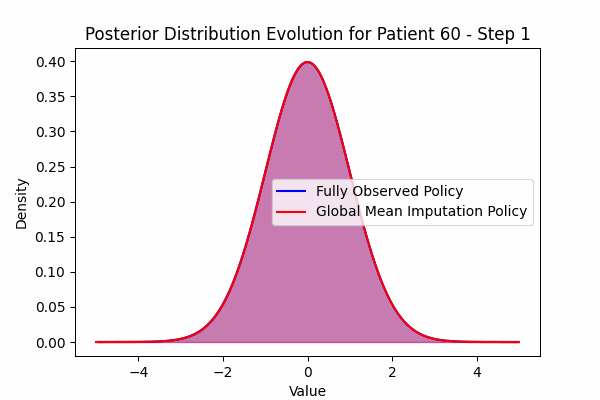

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import imageio

# Load your DataFrame (df_test)
# Assuming df_test is already available with the correct columns

# Define colors for full and miss policies
full_color = "blue"
miss_color = "red"

# Create a range for x-values to plot the Gaussians
x = np.linspace(-5, 5, 1000)

# Store the file paths of images for GIF creation
frames = []

# Iterate through rows to create individual frames
for i, row in df_test.iterrows():
    mean_full, var_full = row["post_mean_0_full"], row["post_var_0_full"]
    mean_miss, var_miss = row["post_mean_0_miss"], row["post_var_0_miss"]
    
    # Compute Gaussian distributions
    y_full = (1 / np.sqrt(2 * np.pi * var_full)) * np.exp(-((x - mean_full) ** 2) / (2 * var_full))
    y_miss = (1 / np.sqrt(2 * np.pi * var_miss)) * np.exp(-((x - mean_miss) ** 2) / (2 * var_miss))

    # Plot distributions
    plt.figure(figsize=(6, 4))
    plt.plot(x, y_full, color=full_color, label="Fully Observed Policy")
    plt.plot(x, y_miss, color=miss_color, label="Global Mean Imputation Policy")
    plt.fill_between(x, y_full, color=full_color, alpha=0.3)
    plt.fill_between(x, y_miss, color=miss_color, alpha=0.3)
    
    plt.title(f"Posterior Distribution Evolution for Patient 60 - Step {i+1}")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    
    # Save each frame
    frame_path = f"frame_{i}.png"
    plt.savefig(frame_path)
    plt.close()
    frames.append(frame_path)

# Create GIF
gif_path = "gaussian_evolution_random22.gif"
imageio.mimsave(gif_path, [imageio.imread(frame) for frame in frames], fps=2)

# Display the GIF
from IPython.display import display, Image
display(Image(gif_path))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

# Define colors for full and miss policies
full_color = "blue"
miss_color = "red"

# Create a range for x-values to plot the Gaussians
x = np.linspace(-5, 5, 1000)

# Store the file paths of images for GIF creation
frames = []

# Iterate through rows up to step 28
for i, row in df_test.iterrows():
    if i >= 28:  # Stop at step 28
        break
    
    mean_full, var_full = row["post_mean_1_full"], row["post_var_1_full"]
    mean_miss, var_miss = row["post_mean_1_miss"], row["post_var_1_miss"]
    
    # Compute Gaussian distributions
    y_full = (1 / np.sqrt(2 * np.pi * var_full)) * np.exp(-((x - mean_full) ** 2) / (2 * var_full))
    y_miss = (1 / np.sqrt(2 * np.pi * var_miss)) * np.exp(-((x - mean_miss) ** 2) / (2 * var_miss))

    # Plot distributions
    plt.figure(figsize=(6, 4))
    plt.plot(x, y_full, color=full_color, label="Full Policy")
    plt.plot(x, y_miss, color=miss_color, linestyle="dashed", label="Miss Policy")
    plt.fill_between(x, y_full, color=full_color, alpha=0.3)
    plt.fill_between(x, y_miss, color=miss_color, alpha=0.3)
    
    plt.title(f"Gaussian Distribution Evolution - Step {i+1}")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    
    # Save each frame
    frame_path = f"frame_{i}.png"
    plt.savefig(frame_path)
    plt.close()
    frames.append(frame_path)

# Create GIF
#gif_path = "gaussian_evolution.gif"
#imageio.mimsave(gif_path, [imageio.imread(frame) for frame in frames], fps=2)

# Display the GIF
from IPython.display import display, Image
display(Image(gif_path))


In [34]:
pd.to_pickle(df_all_results, "../missingness/results/test/df_all_results.pkl")

## Some checks

In [12]:
miss_ids = df_all_results[df_all_results["missing"]==True].groupby("method")["patient_id"].unique()

In [14]:
miss_ids.iloc[0] = np.sort(miss_ids[0])

miss_ids.iloc[1] = np.sort(miss_ids[1])

/tmp/ipykernel_4313/703914433.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  miss_ids.iloc[0] = np.sort(miss_ids[0])
/tmp/ipykernel_4313/703914433.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  miss_ids.iloc[1] = np.sort(miss_ids[1])


In [15]:
miss_ids

method
individual    [0, 4, 6, 7, 8, 9, 13, 16, 19, 20, 22, 25, 28,...
knn           [0, 4, 6, 7, 8, 9, 13, 16, 19, 20, 22, 25, 28,...
Name: patient_id, dtype: object

In [16]:
total_counts = df_all_results.groupby(["method","patient_id"])["missing"].count()

# Step 2: Count occurrences where missing == True
missing_counts = df_all_results.groupby(["method","patient_id"])["missing"].sum()  # sum() works since True=1, False=0

# Step 3: Compute percentage (only for patients who have at least one True)
missing_percentage = (missing_counts / total_counts) * 100
missing_percentage = missing_percentage[missing_counts > 0].reset_index()
#missing_percentage.columns = ["patient_id", "missing_percentage"]

print(missing_percentage)

        method  patient_id    missing
0   individual           0  28.571429
1   individual           4  28.571429
2   individual           6  28.571429
3   individual           7  28.571429
4   individual           8  28.571429
..         ...         ...        ...
95         knn          92  28.571429
96         knn          93  28.571429
97         knn          94  28.571429
98         knn          95  28.571429
99         knn          97  28.571429

[100 rows x 3 columns]


In [17]:
imba_ids = missing_percentage[["patient_id","missing"]].drop_duplicates(keep=False)["patient_id"]

In [18]:
missing_percentage["missing"].value_counts()

missing
28.571429    100
Name: count, dtype: int64

In [ ]:
pd.merge(missing_percentage[(missing_percentage["patient_id"].isin(imba_ids)) & (missing_percentage["method"]=="individual")],
missing_percentage[(missing_percentage["patient_id"].isin(imba_ids)) & (missing_percentage["method"]=="global")],on="patient_id")

In [ ]:
(df_all_results[df_all_results["missing"]]
    .groupby("method")["patient_id"]
    .nunique()
    .reset_index(name="num_patients_with_missing"))

In [ ]:
total_counts = df_all_results.groupby(["method","patient_id"])["missing"].count()

# Step 2: Count occurrences where missing == True
missing_counts = df_all_results.groupby(["method","patient_id"])["missing"].sum()  # sum() works since True=1, False=0

# Step 3: Compute percentage (only for patients who have at least one True)
missing_percentage = (missing_counts / total_counts) * 100
missing_percentage = missing_percentage[missing_counts > 0].reset_index()
#missing_percentage.columns = ["patient_id", "missing_percentage"]

print(missing_percentage)

# Results

### 2,2

In [220]:
df_all_results.groupby(["method","treatment"])["outcome"].mean()

method      treatment
global      0            2.010822
            1            2.040256
ind_tr      0            2.010822
            1            2.040256
individual  0            2.010822
            1            2.040256
knn         0            2.010822
            1            2.040256
locf        0            2.010822
            1            2.040256
Name: outcome, dtype: float64

In [233]:
df_all_results.groupby(["method","treatment_miss"])["outcome_miss"].mean()

method      treatment_miss
global      0                 1.981570
            1                 2.024187
ind_tr      0                 1.988675
            1                 2.032161
individual  0                 1.979378
            1                 2.017926
knn         0                 1.983684
            1                 2.019385
locf        0                 1.989400
            1                 2.006480
Name: outcome_miss, dtype: float64

### 1,0

In [23]:
df_all_results.groupby(["method","treatment"])["outcome"].mean()

method      treatment
cluster     0            1.021751
            1            0.030838
dr          0            1.021751
            1            0.030838
global      0            1.021751
            1            0.030838
global_tr   0            1.021751
            1            0.030838
ind_tr      0            1.021751
            1            0.030838
individual  0            1.021751
            1            0.030838
knn         0            1.021751
            1            0.030838
locf        0            1.021751
            1            0.030838
Name: outcome, dtype: float64

In [24]:
df_all_results.groupby(["method","treatment_miss"])["outcome_miss"].mean()

method      treatment_miss
cluster     0                 0.928418
            1                 0.048959
dr          0                 0.932259
            1                 0.048767
global      0                 0.965766
            1                 0.048767
global_tr   0                 0.997801
            1                 0.048767
ind_tr      0                 1.001849
            1                 0.057047
individual  0                 0.957755
            1                 0.074547
knn         0                 0.963033
            1                 0.048767
locf        0                 0.980094
            1                 0.050404
Name: outcome_miss, dtype: float64

## Percentage of optimal treatment selection

In [25]:
optimal_miss_perc2 = df_all_results.groupby(['method', 'patient_id'])['treatment_miss']\
    .value_counts(normalize=True)\
    .unstack()\
    .mul(100)\
    .fillna(0)

# Compute mean and standard deviation per method
summary_miss = optimal_miss_perc2.groupby("method").agg(["mean", "std"]).round(2)

# Rename columns for clarity
summary_miss.columns = ["percentage_miss_0_mean", "percentage_miss_0_std", 
                   "percentage_miss_1_mean", "percentage_miss_1_std"]

# Reset index for readability
summary_miss = summary_miss.reset_index()

optimal_perc2 = df_all_results.groupby(['method', 'patient_id'])['treatment']\
    .value_counts(normalize=True)\
    .unstack()\
    .mul(100)\
    .fillna(0)

# Compute mean and standard deviation per method
summary_full = optimal_perc2.groupby("method").agg(["mean", "std"]).round(2)

# Rename columns for clarity
summary_full.columns = ["percentage_full_0_mean", "percentage_full_0_std", 
                   "percentage_full_1_mean", "percentage_full_1_std"]

# Reset index for readability
summary_full = summary_full.reset_index()

### 2,2

In [227]:
pd.merge(summary_full,summary_miss,on="method")

,method,percentage_full_0_mean,percentage_full_0_std,percentage_full_1_mean,percentage_full_1_std,percentage_miss_0_mean,percentage_miss_0_std,percentage_miss_1_mean,percentage_miss_1_std
0,global,58.11,36.86,41.89,36.86,53.18,28.03,46.82,28.03
1,ind_tr,58.11,36.86,41.89,36.86,56.18,38.84,43.82,38.84
2,individual,58.11,36.86,41.89,36.86,55.61,38.03,44.39,38.03
3,knn,58.11,36.86,41.89,36.86,49.39,28.95,50.61,28.95
4,locf,58.11,36.86,41.89,36.86,56.18,38.00,43.82,38.00


### 1,0

In [27]:
pd.merge(summary_full,summary_miss,on="method")

,method,percentage_full_0_mean,percentage_full_0_std,percentage_full_1_mean,percentage_full_1_std,percentage_miss_0_mean,percentage_miss_0_std,percentage_miss_1_mean,percentage_miss_1_std
0,cluster,84.57,15.42,15.43,15.42,90.89,12.56,9.11,12.56
1,dr,84.57,15.42,15.43,15.42,90.93,12.58,9.07,12.58
2,global,84.57,15.42,15.43,15.42,90.93,12.58,9.07,12.58
3,global_tr,84.57,15.42,15.43,15.42,90.93,12.58,9.07,12.58
4,ind_tr,84.57,15.42,15.43,15.42,82.68,18.63,17.32,18.63
5,individual,84.57,15.42,15.43,15.42,81.36,18.28,18.64,18.28
6,knn,84.57,15.42,15.43,15.42,90.93,12.58,9.07,12.58
7,locf,84.57,15.42,15.43,15.42,82.07,17.44,17.93,17.44


In [ ]:
optimal_miss_abs = pd.DataFrame(df_all_results.groupby(["method"])["treatment_miss"].value_counts()).reset_index()
optimal_miss_abs.columns = ["method","treatment","count_miss"]

In [ ]:
optimal_full_abs = df_all_results.groupby(["method"])["treatment"].value_counts().reset_index()
optimal_full_abs.columns = ["method","treatment","count_full"]

In [ ]:
optimal_abs = pd.merge(optimal_full_abs,optimal_miss_abs,on=["method","treatment"])
optimal_abs[optimal_abs["treatment"]==0]

# KL divergence

In [ ]:
def kl_divergence_norm(mu_p, sigma_p, mu_q, sigma_q):
    """Compute KL divergence D_KL(P || Q) for two normal distributions."""
    return np.log(sigma_q / sigma_p) + (sigma_p**2 + (mu_p - mu_q)**2) / (2 * sigma_q**2) - 0.5

In [ ]:
means_vars_obs = df_all_results.groupby(["method","treatment"])["outcome"].agg({lambda x:(np.mean(x),np.var(x))}).reset_index()

means_vars_obs.rename(columns={"<lambda>":"means_vars"},inplace=True)

In [ ]:
means_vars_miss = df_all_results.groupby(["method","treatment"])["outcome_miss"].agg({lambda x:(np.mean(x),np.var(x))}).reset_index()

means_vars_miss.rename(columns={"<lambda>":"means_vars"},inplace=True)

In [ ]:
true_mu_0, true_sigma_0 = (treatment_means[0],treatment_vars[0])
true_mu_1, true_sigma_1 = (treatment_means[1],treatment_vars[1])


In [ ]:
miss_true_kl = pd.DataFrame(columns=["method","treatment","KL_miss_true"], index=range(len(imputation_method_names)))
for i, row in means_vars_miss.iterrows():
    method = row["method"]
    treatment = row["treatment"]
    mean = row["means_vars"][0]
    sigma = row["means_vars"][1]
    if treatment == 0:
        true_mu = true_mu_0
        true_sigma = true_sigma_0
    else:
        true_mu = true_mu_1
        true_sigma = true_sigma_1
    kl = kl_divergence_norm(mean, sigma, true_mu, true_sigma)
    miss_true_kl.loc[i,"method"] = method
    miss_true_kl.loc[i,"treatment"] = treatment
    miss_true_kl.loc[i,"KL_miss_true"] = kl 

In [ ]:
obs_true_kl = pd.DataFrame(columns=["method","treatment","KL_obs_true"], index=range(len(imputation_method_names)))


for i, row in means_vars_obs.iterrows():
    method = row["method"]
    treatment = row["treatment"]
    mean = row["means_vars"][0]
    sigma = row["means_vars"][1]
    if treatment == 0:
        true_mu = true_mu_0
        true_sigma = true_sigma_0
    else:
        true_mu = true_mu_1
        true_sigma = true_sigma_1
    kl = kl_divergence_norm(mean, sigma, true_mu, true_sigma)
    obs_true_kl.loc[i,"method"] = method
    obs_true_kl.loc[i,"treatment"] = treatment
    obs_true_kl.loc[i,"KL_obs_true"] = kl 

In [ ]:
obs_miss_kl = pd.DataFrame(columns=["method","treatment","KL_obs_miss"], index=range(len(imputation_method_names)))

for i, row in means_vars_miss.iterrows():
    method = row["method"]
    treatment = row["treatment"]
    mean = row["means_vars"][0]
    sigma = row["means_vars"][1]
    mean_full = means_vars_obs.iloc[i]["means_vars"][0]
    sigma_full = means_vars_obs.iloc[i]["means_vars"][1]
    kl = kl_divergence_norm(mean, sigma, mean_full, sigma_full)
    obs_miss_kl.loc[i,"method"] = method
    obs_miss_kl.loc[i,"treatment"] = treatment
    obs_miss_kl.loc[i,"KL_obs_miss"] = kl 

In [ ]:
kl_divs = pd.merge(obs_true_kl, miss_true_kl, on=["method","treatment"])

In [ ]:
kl_divs = pd.merge(obs_miss_kl, kl_divs, on=["method","treatment"])

In [ ]:
kl_divs

## Descriptives & visual comparison

In [ ]:
df_plot =pd.melt(df_all_results[df_all_results["patient_id"]==4],
       id_vars=["method","patient_id","t","treatment","treatment_miss"],
       value_vars=["outcome","outcome_miss"])

df_plot.loc[df_plot["variable"]=="outcome","method"] = "full"

df_plot.drop_duplicates(inplace=True)

sns.scatterplot(df_plot,x="t",y="value",hue="method")

In [ ]:
df_all_results.groupby("method")["outcome"]

In [ ]:
import seaborn as sns

In [ ]:
g = sns.displot(kind='kde', data=df_all_results[df_all_results["treatment"]==0], x='outcome', row="method", hue="method", fill=True, common_norm=False, alpha=0.4)
for ax in g.axes.flat:
    ax.axvline(2,color="red")

## Posterior difference plots

In [ ]:
posterior_diff = df_all_results.groupby(["method","patient_id"]).apply(lambda x:x[x["treatment"]==0]["outcome"].reset_index(drop=True) - x[x["treatment"]==1]["outcome"].reset_index(drop=True)).reset_index()

In [ ]:
posterior_diff_miss = df_all_results.groupby(["method","patient_id"]).apply(lambda x:x[x["treatment"]==0]["outcome_miss"].reset_index(drop=True) - x[x["treatment"]==1]["outcome_miss"].reset_index(drop=True)).reset_index()

In [ ]:
posterior_tru = np.random.normal(2, 1, df_all_results.shape[0])
posterior_tru_0 = np.random.normal(0, 1, df_all_results[df_all_results["treatment"]==0].shape[0])
posterior_tru_1 = np.random.normal(2, 1, df_all_results[df_all_results["treatment"]==1].shape[0])

In [ ]:
posterior_diff["diff"] = "full"
posterior_diff_miss["diff"] = "miss"

In [ ]:
all_posterior_diff = pd.concat([posterior_diff,posterior_diff_miss.rename(columns={"outcome_miss":"outcome"})],axis=0).reset_index(drop=True)

In [ ]:
g = sns.displot(kind='kde', data=all_posterior_diff, x='outcome', col="diff",row="method", hue="method", fill=True, common_norm=False, alpha=0.4)
for ax in g.axes.flat:
    ax.axvline(2,color="red")

In [ ]:
g = sns.displot(kind='kde', data=posterior_diff_miss, x='outcome_miss', row="method", hue="method", fill=True, common_norm=False, alpha=0.4)
for ax in g.axes.flat:
    ax.axvline(2,color="red")

In [ ]:
# Plot the result
sns.kdeplot(posterior_diff["outcome"], fill=True, label="Posterior Difference")
plt.axvline(np.mean(posterior_diff["outcome"]), color="red", linestyle="--", label="Mean Difference")
plt.legend()
plt.title("Posterior of the Difference (P1 - P2)")
plt.show()

In [ ]:
# Plot the result
sns.kdeplot(posterior_diff_miss["outcome_miss"], fill=True, label="Posterior Difference Treatment 0")
plt.axvline(np.mean(posterior_diff_miss["outcome_miss"]), color="red", linestyle="--", label="Mean Difference Treatment 0")
plt.legend()
plt.title("Posterior of the Difference (P1 - P2)")
plt.show()

In [ ]:
# Data Generation Model
class PooledNormalModel(Model):
    def __init__(self, patient_id, prior_mean, prior_variance, variance):
        self.rng = numpy.random.default_rng(patient_id)
        self.prior_mean = prior_mean
        self.prior_variance = prior_variance
        self.variance = variance
        self.patient_id = patient_id

        # Draw patient effects randomly:
        self.mean = self.rng.normal(prior_mean, numpy.sqrt(prior_variance))

    def generate_context(self, history):
        return {}

    @property
    def additional_config(self):
        return {"expectations_of_interventions": self.mean}

    @property
    def number_of_interventions(self):
        return len(self.prior_mean)

    def observe_outcome(self, action, context, missing=False):
        treatment_index = action["treatment"]
        outcome = self.rng.normal(
                self.mean[treatment_index], numpy.sqrt(self.variance[treatment_index])
            )
        if missing:
            return {
                "outcome_miss": outcome
            }
        else:
            return {
            "outcome": outcome
        }

    def __str__(self):
        return (
            f"PooledNormalModel({self.prior_mean, self.prior_variance, self.variance})"
        )

In [ ]:
# Inference Model


class PooledNormalWithKnownVariance(BayesianModel):
    def __str__(self):
        return f"PooledNormalWithKnownVariance"

    def update_posterior(self, history, number_of_treatments):
        # Simple model with baseline + treatment effects + noise
        df = history.to_df()

        self.model = pymc.Model()
        with self.model:
            treatment_index = pymc.MutableData(
                "treatment_index",
                pymc.intX(df[self.treatment_name]),
                dims="observation",
            )
            patient_index = pymc.MutableData(
                "patient_index", pymc.intX(df["patient_id"]), dims="observation"
            )
            sigma = pymc.Uniform("sigma", lower=0.1, upper=2.0)
            mu_treatment = pymc.Normal(
                "mu_treatment", mu=0, sigma=sigma, dims="treatment", shape=2
            )
            mu_treatment_patient = pymc.Normal(
                "mu_patient_treatment",
                mu=mu_treatment,
                sigma=1,
                dims=("patient", "treatment"),
                shape=(10, 2),
            )
            outcome = pymc.Normal(
                "outcome",
                mu=mu_treatment_patient[patient_index, treatment_index],
                observed=df["outcome"],
                sigma=1,
                dims="observation",
                shape=len(df["outcome"]),
            )
            self.trace = pymc.sample(2000, progressbar=False)

    def approximate_max_probabilities(self, number_of_treatments, context):
        assert (
            self.trace is not None
        ), "You called `approximate_max_probabilites` without updating the posterior"

        # Todo: we need to use the patient_id here
        patient_id = context["patient_id"]
        self.patient_id = patient_id
        with self.model:
            pymc.set_data(
                {
                    "treatment_index": pymc.intX([0, 1]),
                    "patient_index": pymc.intX([patient_id] * 2),
                }
            )
            self.trace = pymc.sample_posterior_predictive(
                self.trace,
                var_names=["mu_patient_treatment"],
                extend_inferencedata=True,
            )
            max_indices = np.ravel(
                self.trace.posterior_predictive["mu_patient_treatment"].argmax(
                    dim="treatment"
                )
            )
        bin_counts = np.bincount(max_indices, minlength=number_of_treatments)
        return bin_counts / np.sum(bin_counts)

    def get_upper_confidence_bounds(self, variable_name, epsilon: float = 0.05):
        confidence_bounds = arviz.hdi(
            self.trace.posterior_predictive,
            var_names=[variable_name],
            hdi_prob=1 - epsilon,
        )
        # The data containts always (lower, upper) for all patients, and we only want higher for the right patient
        return confidence_bounds[variable_name][self.patient_id, :, 1].to_numpy()


generating_pooling_scenario_VI = lambda patient_id: PooledNormalModel(
    patient_id, prior_mean=[1, 0], prior_variance=[0.8, 0.8], variance=[1, 1]
)
generating_pooling_scenario_VII = lambda patient_id: PooledNormalModel(
    patient_id, prior_mean=[1, 0], prior_variance=[1.5, 1.5], variance=[1, 1]
)

In [ ]:
# Policies
pooled_fixed_policy = BlockPolicy(
    block_length=block_length,
    internal_policy=FixedPolicy(
        inference_model=PooledNormalWithKnownVariance(),
    ),
)

pooled_thompson_sampling_policy = BlockPolicy(
    block_length=block_length,
    internal_policy=ThompsonSampling(
        inference_model=PooledNormalWithKnownVariance(),
        outcome_name="mu_patient_treatment",
    ),
)

pooled_ucb_policy = BlockPolicy(
    block_length=block_length,
    internal_policy=UpperConfidenceBound(
        inference_model=PooledNormalWithKnownVariance(),
        outcome_name="mu_patient_treatment",
        epsilon=0.05,
    ),
)

In [ ]:
configurations = []
# Pooling
study_designs = {
    "n_patients": [10],
    "policy": [pooled_ucb_policy, pooled_thompson_sampling_policy],
    "model_from_patient_id": [
        generating_pooling_scenario_VI,
        generating_pooling_scenario_VII,
    ],
    "pooling": [True],
}
configurations.extend(generate_configuration_cross_product(study_designs))

In [ ]:
plot_allocations_for_calculated_series(calculated_series)

In [ ]:
metrics = [
    SimpleRegretWithBayesian(),
    CumulativeRegret(),
]
df = SeriesOfSimulationsData.score_data(
    [s["result"] for s in calculated_series],
    metrics,
    {"model": lambda x: model_mapping[x], "policy": lambda x: policy_mapping[x]},
)
filtered_df = df.loc[df["t"] == df["t"].max()]

groupby_columns = ["model", "policy"]
pivoted_df = filtered_df.pivot(
    index=["model", "policy", "simulation", "patient_id"],
    columns="metric",
    values="score",
)


policy_ordering = ["UCB", "TS", "Pooled TS", "Pooled UCB"]
table = pivoted_df.groupby(groupby_columns).agg(["mean", "std"])
# Convert the 'policy' column in the MultiIndex to a Categorical type with the specified order
table = table.reset_index()
table["policy"] = pd.Categorical(
    table["policy"], categories=policy_ordering, ordered=True
)

# Sort the DataFrame first by 'model' then by the now-ordered 'policy'
sorted_table = (
    table.sort_values(by=["model", "policy"])
    .set_index(groupby_columns)
    .rename(
        columns={
            "Cumulative Regret (outcome)": "Regret",
            "Simple Regret With Mean": "$\SIR$",
            "Best Arm Identification With Mean": "$\BAI$",
            "KL Divergence": "$\KLD$",
        },
    )
)
# sorted_table.index.names = ["S.", "Policy"]
sorted_table

In [ ]:
with open("mt_resources/5-optimization/02-table-pooling.tex", "w") as file:
    str = sorted_table.style.format(precision=2).to_latex(hrules=True)
    print(str)
    file.write(str)

In [ ]:
def rename_df(df):
    df["policy_#_metric_#_model_p"] = df["policy"].apply(lambda x: policy_mapping[x])
    df["policy_#_metric_#_model_p"] = pd.Categorical(
        df["policy_#_metric_#_model_p"], categories=policy_ordering, ordered=True
    )
    return df


SeriesOfSimulationsData.plot_lines(
    [s["result"] for s in calculated_series],
    [
        CumulativeRegret(),
    ],
    legend_position=(1, 1),
)
plt.savefig(
    "mt_resources/5-optimization/03_pooled_cumulative_regret.pdf", bbox_inches="tight"
)

In [ ]:
ax = SeriesOfSimulationsData.plot_lines(
    [
        s["result"]
        for s in calculated_series
        if s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [1.5, 1.5], [1, 1]))"
    ],
    [
        CumulativeRegret(),
    ],
    legend_position=(0.02, 0.3),
    process_df=rename_df,
)
plt.ylabel("Regret")

seaborn.move_legend(ax, "lower left", title=None)
plt.savefig(
    "mt_resources/5-optimization/03-pooled-cumulative_regret_high_sigma.pdf",
    bbox_inches="tight",
)

In [ ]:
ax = SeriesOfSimulationsData.plot_lines(
    [
        s["result"]
        for s in calculated_series
        if s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [1.5, 1.5], [1, 1]))"
    ],
    [
        SimpleRegretWithBayesian(),
    ],
    process_df=rename_df,
)
plt.ylabel("Simple Regret")

seaborn.move_legend(ax, "upper right", title=None)
plt.savefig(
    "mt_resources/5-optimization/03-pooled-simple_regret-high-sigma.pdf",
    bbox_inches="tight",
)

In [ ]:
ax = SeriesOfSimulationsData.plot_lines(
    [
        s["result"]
        for s in calculated_series
        if s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [0.8, 0.8], [1, 1]))"
    ],
    [
        CumulativeRegret(),
    ],
    legend_position=(0.02, 0.3),
    process_df=rename_df,
)
plt.ylabel("Regret")
seaborn.move_legend(ax, "lower left", title=None)
plt.savefig(
    "mt_resources/5-optimization/03-pooled-cumulative_regret-low_sigma.pdf",
    bbox_inches="tight",
)

In [ ]:
ax = SeriesOfSimulationsData.plot_lines(
    [
        s["result"]
        for s in calculated_series
        if s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [0.8, 0.8], [1, 1]))"
    ],
    [
        SimpleRegretWithBayesian(),
    ],
    process_df=rename_df,
)

seaborn.move_legend(ax, "upper right", title=None)
plt.ylabel("Simple Regret")
plt.savefig(
    "mt_resources/5-optimization/03-pooled-simple_regret-low_sigma.pdf",
    bbox_inches="tight",
)

In [ ]:
plot_allocations_for_calculated_series(
    [
        s
        for s in calculated_series
        if s["configuration"]["policy"]
        == "BlockPolicy(UpperConfidenceBound(0.05 epsilon, PooledNormalWithKnownVariance))"
        and s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [0.8, 0.8], [1, 1]))"
    ]
)

In [ ]:
plot_allocations_for_calculated_series(
    [
        s
        for s in calculated_series
        if s["configuration"]["policy"]
        == "BlockPolicy(UpperConfidenceBound(0.05 epsilon, PooledNormalWithKnownVariance))"
        and s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [1.5, 1.5], [1, 1]))"
    ]
)

In [ ]:
plot_allocations_for_calculated_series(
    [
        s
        for s in calculated_series
        if s["configuration"]["policy"]
        == "BlockPolicy(ThompsonSampling(PooledNormalWithKnownVariance))"
        and s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [0.8, 0.8], [1, 1]))"
    ]
)

In [ ]:
plot_allocations_for_calculated_series(
    [
        s
        for s in calculated_series
        if s["configuration"]["policy"]
        == "BlockPolicy(ThompsonSampling(PooledNormalWithKnownVariance))"
        and s["configuration"]["model"]
        == "PooledNormalModel(([1, 0], [1.5, 1.5], [1, 1]))"
    ]
)